# xgboost_code

XGBoost construye árboles de forma secuencial y corrige los errores residuales anteriores. La optimización utiliza una búsqueda aleatoria amplia seguida de una búsqueda en rejilla más focalizada, con `TimeSeriesSplit` para conservar el orden temporal durante la validación. La regularización y el submuestreo son importantes cuando el dataset es pequeño.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install xgboost scikit-learn matplotlib pandas numpy


>> Ejecutando Optimización (Random + Grid Search)...
Mejores hiperparámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.9}


--- RESULTADOS FINALES (XGBoost) ---
MAPE: 6.05%  |  MAE: 173,528  |  R2: 0.9243



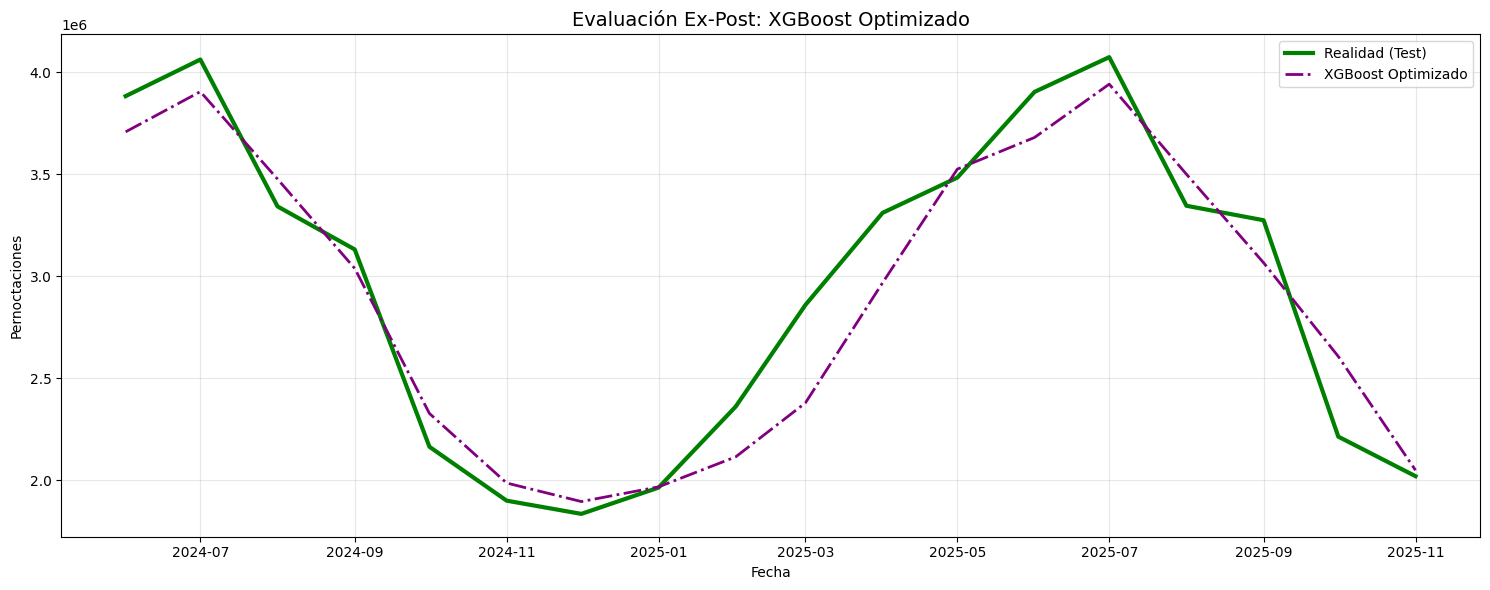

 PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)
Umbral Verde/Naranja: 1,834,345 pernoctaciones
Umbral Naranja/Rojo:  3,018,909 pernoctaciones
Aciertos de nivel de alerta: 94.4% (17/18 meses)

fecha_objetivo  pernoctaciones_real  pernoctaciones_predicha ipt_real  codigo_real ipt_predicho  codigo_predicho  acierto_nivel
    2024-06-01            3881922.0             3.707008e+06     Rojo            2         Rojo                2           True
    2024-07-01            4061207.0             3.903944e+06     Rojo            2         Rojo                2           True
    2024-08-01            3341674.0             3.475671e+06     Rojo            2         Rojo                2           True
    2024-09-01            3130930.0             3.037983e+06     Rojo            2         Rojo                2           True
    2024-10-01            2164179.0             2.327352e+06  Naranja            1      Naranja                1           True
    2024-11-01            1900241.0       

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. CARGA DE DATOS Y CONSTRUCCIÓN DE LA SERIE DIFERENCIADA

RUTA_DATOS = "/content/drive/MyDrive/VIU/TFM/Data/DATASET_TFM_FINAL.csv"
TARGET = "Pernoctaciones"
HORIZONTE = 1     # meses de antelación
MESES_TEST = 18   # ventana de test

df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"], index_col="fecha")
df = df.sort_index()
y_abs = df[TARGET]

# Safe features (sin fuga de información temporal)
df["pernoctaciones_lag_1"] = y_abs.shift(1)
df["pernoctaciones_lag_2"] = y_abs.shift(2)
df["pernoctaciones_lag_3"] = y_abs.shift(3)
df["pernoctaciones_roll_mean_3"] = y_abs.shift(1).rolling(3).mean()
df["pernoctaciones_roll_mean_12"] = y_abs.shift(1).rolling(12).mean()
df["pernoctaciones_roll_std_3"] = y_abs.shift(1).rolling(3).std()
df["pernoctaciones_ewm_12"] = y_abs.shift(1).ewm(span=12, adjust=False).mean()
df["yoy_growth_lag1"] = y_abs.pct_change(12).shift(1).replace([np.inf, -np.inf], np.nan)
df["pernoctaciones_diff_lag_1"] = y_abs.diff().shift(1)

SAFE_FEATURES = [
    "mes_sin", "mes_cos", "es_festivo", "es_fin_semana", "dia_libre_real", "es_covid",
    "pernoctaciones_lag_1", "pernoctaciones_lag_2", "pernoctaciones_lag_3",
    "pernoctaciones_roll_mean_3", "pernoctaciones_roll_mean_12",
    "pernoctaciones_roll_std_3", "pernoctaciones_ewm_12", "yoy_growth_lag1",
    "pernoctaciones_diff_lag_1",
    "llegadas_lag_1", "llegadas_lag_2",
    "barcelona flights_lag_1", "barcelona flights_lag_2",
    "barcelona hotel_lag_1", "barcelona hotel_lag_2",
    "airbnb barcelona_lag_1", "airbnb barcelona_lag_2",
]


def build_dataset_diff(data, h, features, target=TARGET):
    """X (features seguras en t) e y_diff = valor absoluto(t+h) - valor absoluto(t).
    El shift(-h) se calcula ANTES del dropna para no desalinear las fechas."""
    d = data.copy()
    d["y_abs_objetivo"] = d[target].shift(-h)
    d["y_diff_h"] = d["y_abs_objetivo"] - d[target]
    d = d.dropna(subset=features + ["y_diff_h"])
    X = d[features]
    y_diff = d["y_diff_h"]
    y_abs_ancla = d[target]
    y_abs_objetivo = d["y_abs_objetivo"]
    return X, y_diff, y_abs_ancla, y_abs_objetivo


X, y_diff, y_abs_ancla, y_abs_obj = build_dataset_diff(df, HORIZONTE, SAFE_FEATURES)

X_train, X_test = X.iloc[:-MESES_TEST], X.iloc[-MESES_TEST:]
y_train_diff, y_test_diff = y_diff.iloc[:-MESES_TEST], y_diff.iloc[-MESES_TEST:]
y_test_abs = y_abs_obj.iloc[-MESES_TEST:]
y_ancla_test = y_abs_ancla.iloc[-MESES_TEST:]


# 2. DOBLE OPTIMIZACIÓN XGBOOST
tscv = TimeSeriesSplit(n_splits=4)
xgb_base = XGBRegressor(random_state=42, objective="reg:squarederror", n_jobs=-1)

print(">> Ejecutando Optimización (Random + Grid Search)...")
espacio_xgb_random = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "reg_alpha": [0, 0.5, 1],
    "reg_lambda": [1, 2, 5],
}

random_search = RandomizedSearchCV(
    estimator=xgb_base, param_distributions=espacio_xgb_random,
    n_iter=20, cv=tscv, scoring="neg_mean_absolute_error",
    random_state=42, n_jobs=-1, verbose=0,
)
random_search.fit(X_train, y_train_diff)
mejores = random_search.best_params_

espacio_xgb_grid = {
    "n_estimators": [mejores["n_estimators"]],
    "learning_rate": [mejores["learning_rate"] * 0.9, mejores["learning_rate"], mejores["learning_rate"] * 1.1],
    "max_depth": [mejores["max_depth"]],
    "subsample": [mejores["subsample"]],
    "colsample_bytree": [mejores["colsample_bytree"]],
    "reg_alpha": [mejores["reg_alpha"]],
    "reg_lambda": [mejores["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=xgb_base, param_grid=espacio_xgb_grid, cv=tscv,
    scoring="neg_mean_absolute_error", n_jobs=-1, verbose=0,
)
grid_search.fit(X_train, y_train_diff)
modelo_xgb_opt = grid_search.best_estimator_

print(f"Mejores hiperparámetros: {grid_search.best_params_}\n")


# 3. PREDICCIÓN Y RECONSTRUCCIÓN MATEMÁTICA
predicciones_diff = pd.Series(modelo_xgb_opt.predict(X_test), index=y_test_diff.index)
predicciones_abs = y_ancla_test + predicciones_diff

# 4. MÉTRICAS DE EVALUACIÓN FINAL (SOBRE VALORES ABSOLUTOS, HORIZONTE 1 MES)
mae = mean_absolute_error(y_test_abs, predicciones_abs)
rmse = np.sqrt(mean_squared_error(y_test_abs, predicciones_abs))
mape = np.mean(np.abs((y_test_abs - predicciones_abs) / y_test_abs)) * 100
r2 = r2_score(y_test_abs, predicciones_abs)

print(f"\n--- RESULTADOS FINALES (XGBoost) ---")
print(f"MAPE: {mape:.2f}%  |  MAE: {mae:,.0f}  |  R2: {r2:.4f}\n")

# 5. VISUALIZACIÓN
plt.figure(figsize=(15, 6))
plt.plot(y_test_abs.index, y_test_abs, label='Realidad (Test)', color='green', linewidth=3)
plt.plot(predicciones_abs.index, predicciones_abs, label='XGBoost Optimizado', color='purple', linestyle='-.', linewidth=2)
plt.title('Evaluación Ex-Post: XGBoost Optimizado', fontsize=14)
plt.ylabel('Pernoctaciones')
plt.xlabel('Fecha')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("xgboost_h1_ipt_final.png", dpi=110)
plt.show()

# 6. ÍNDICE DE PRESIÓN TURÍSTICA (IPT) - 3 NIVELES DE ALERTA
# Verde   -> presión turística baja/moderada (nivel menos grave)
# Naranja -> presión turística alta (nivel intermedio)
# Rojo    -> presión turística muy alta / saturación (nivel más grave)
#
# Los umbrales se definen sobre los terciles (P33 y P66) del histórico
# COMPLETO de pernoctaciones observadas, de forma que cada nivel representa
# aproximadamente un tercio de los meses históricos. Es un proxy: la fórmula
# completa del IPT (ocupación 40% + tráfico 25% + concentración 20% +
# infraestructura 15%) requiere las otras 3 variables cuando estén
# disponibles.
UMBRAL_VERDE_NARANJA, UMBRAL_NARANJA_ROJO = np.percentile(y_abs, [33, 66])

NIVELES_IPT = {
    0: "Verde",
    1: "Naranja",
    2: "Rojo",
}


def clasificar_ipt(valor_pernoctaciones):
    """Devuelve (nivel_texto, codigo_numerico) donde 0=Verde (menos grave)
    y 2=Rojo (más grave)."""
    if valor_pernoctaciones < UMBRAL_VERDE_NARANJA:
        codigo = 0
    elif valor_pernoctaciones < UMBRAL_NARANJA_ROJO:
        codigo = 1
    else:
        codigo = 2
    return NIVELES_IPT[codigo], codigo


# 6.1 Alertas IPT sobre todo el conjunto de test
alertas_test = pd.DataFrame({
    "fecha_objetivo": y_test_abs.index,
    "pernoctaciones_real": y_test_abs.values,
    "pernoctaciones_predicha": predicciones_abs.values,
})
alertas_test[["ipt_real", "codigo_real"]] = alertas_test["pernoctaciones_real"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test[["ipt_predicho", "codigo_predicho"]] = alertas_test["pernoctaciones_predicha"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test["acierto_nivel"] = alertas_test["codigo_real"] == alertas_test["codigo_predicho"]

precision_semaforo = alertas_test["acierto_nivel"].mean() * 100
print("=" * 45)
print(" PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)")
print("=" * 45)
print(f"Umbral Verde/Naranja: {UMBRAL_VERDE_NARANJA:,.0f} pernoctaciones")
print(f"Umbral Naranja/Rojo:  {UMBRAL_NARANJA_ROJO:,.0f} pernoctaciones")
print(f"Aciertos de nivel de alerta: {precision_semaforo:.1f}% ({alertas_test['acierto_nivel'].sum()}/{len(alertas_test)} meses)\n")
print(alertas_test.to_string(index=False))

# 6.2 Matriz de confusión simple entre niveles
matriz_confusion = pd.crosstab(
    alertas_test["ipt_real"], alertas_test["ipt_predicho"],
    rownames=["Real"], colnames=["Predicho"]
).reindex(index=["Verde", "Naranja", "Rojo"], columns=["Verde", "Naranja", "Rojo"], fill_value=0)
print("\nMatriz de confusión (niveles IPT):")
print(matriz_confusion)


# 7. EXPORTAR RESULTADOS
resumen_metrico = pd.DataFrame([{
    "Horizonte (meses)": HORIZONTE,
    "MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2,
    "Precision_semaforo (%)": precision_semaforo,
}])
resumen_metrico.to_csv("resultados_xgboost_ipt_h1.csv", index=False)
alertas_test.to_csv("alertas_ipt_h1_test.csv", index=False)
matriz_confusion.to_csv("matriz_confusion_ipt_h1.csv")

print("\nArchivos exportados: resultados_xgboost_ipt_h1.csv, alertas_ipt_h1_test.csv, "
      "matriz_confusion_ipt_h1.csv, xgboost_h1_ipt_final.png")
